In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
from PDESolver import *

# 1D Tests in Dirichlet conditions

## 1D stationnary equation with psiOp()


*********************************
* Partial differential equation *
*********************************

     ⎛ 2          ⎞         
psiOp⎝ξ  + 1, u(x)⎠ = sin(x)

********************
* Equation parsing *
********************


Equation rewritten in standard form: -sin(x) + psiOp(xi**2 + 1, u(x))
⚠️ psiOp detected: skipping expansion for safety

Expanded equation: -sin(x) + psiOp(xi**2 + 1, u(x))
Analyzing term: -sin(x)
  --> Classified as source term
Analyzing term: psiOp(xi**2 + 1, u(x))
  --> Classified as pseudo linear term (psiOp)
Final linear terms: {}
Final nonlinear terms: []
Symbol terms: []
Pseudo terms: [(1, xi**2 + 1)]
Source terms: [-sin(x)]
⚠️  Pseudo‑differential operator detected: all other linear terms have been rejected.

symbol = 
 2    
ξ  + 1
⚠️ For psiOp, use interactive_symbol_analysis.

*******************************
* Solving the stationnary PDE *
*******************************

boundary condition:  dirichlet

symbol = 
 2    
ξ  + 1
✅ Elliptic pseudo-differe

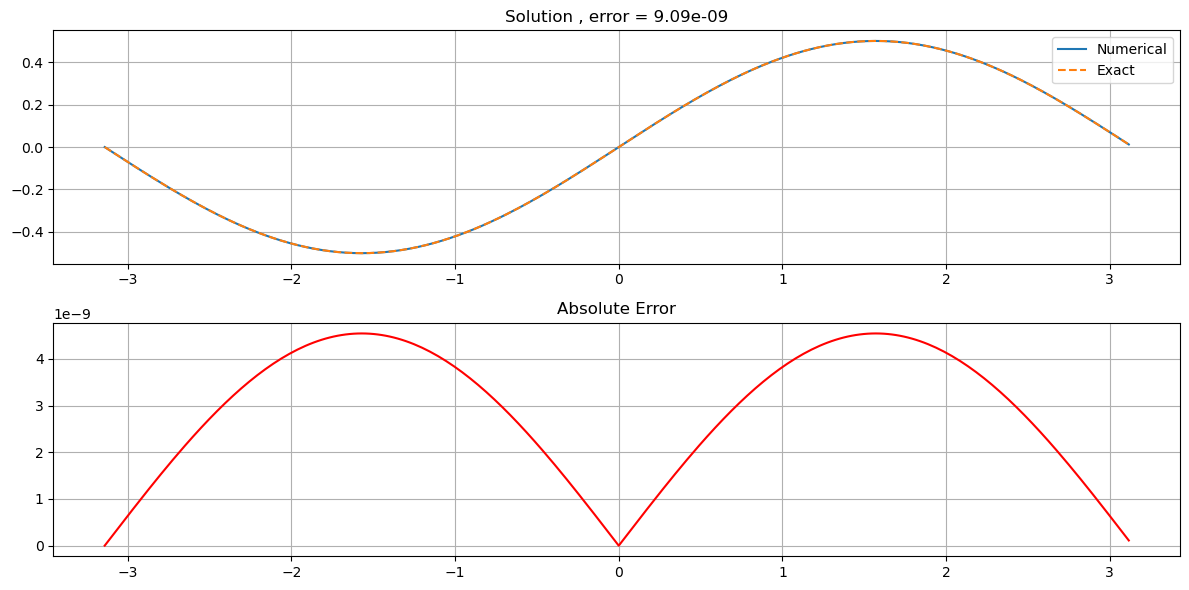

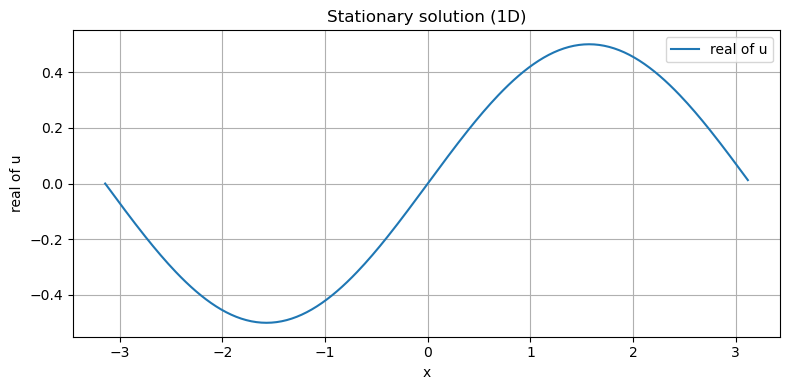

In [3]:
# Define symbolic variables
x = symbols('x')
xi = symbols('xi', real=True)
u = Function('u')(x)

# Equation: psiOp(xi^2 + 1, u)(x) = sin(x)
equation = Eq(psiOp(xi**2 + 1, u), sin(x))

# Exact solution (for testing)
def u_exact(x_vals):
    return np.sin(x_vals) / 2  # Uses numpy, not sympy

# Create the solver
solver = PDESolver(equation)

# Grid parameters
Lx = 2 * np.pi
Nx = 256

# Configure the solver with Dirichlet boundary condition
solver.setup(
    Lx=Lx,
    Nx=Nx,
    boundary_condition='dirichlet',
    initial_condition=None  # Not necessary for a stationary problem
)

# Solve the stationary problem
u_num = solver.solve_stationary_psiOp(order=1)

# Exact solution on grid
u_ref = u_exact(solver.X)

# Compute relative L2 error
error = np.linalg.norm(np.real(u_num) - u_ref) / np.linalg.norm(u_ref)

# Automatic test (uses the well-vectorized u_exact function)
solver.test(u_exact=u_exact, threshold=5e-3, component='real')

# Visualization of the solution
solver.show_stationary_solution(u=u_num, component='real')


## 1D stationnary equation with psiOp() depending on $x$


*********************************
* Partial differential equation *
*********************************

     ⎛ 2  2          ⎞         
psiOp⎝x ⋅ξ  + 1, u(x)⎠ = sin(x)

********************
* Equation parsing *
********************


Equation rewritten in standard form: -sin(x) + psiOp(x**2*xi**2 + 1, u(x))
⚠️ psiOp detected: skipping expansion for safety

Expanded equation: -sin(x) + psiOp(x**2*xi**2 + 1, u(x))
Analyzing term: -sin(x)
  --> Classified as source term
Analyzing term: psiOp(x**2*xi**2 + 1, u(x))
  --> Classified as pseudo linear term (psiOp)
Final linear terms: {}
Final nonlinear terms: []
Symbol terms: []
Pseudo terms: [(1, x**2*xi**2 + 1)]
Source terms: [-sin(x)]
⚠️  Pseudo‑differential operator detected: all other linear terms have been rejected.

symbol = 
 2  2    
x ⋅ξ  + 1
⚠️ For psiOp, use interactive_symbol_analysis.

*******************************
* Solving the stationnary PDE *
*******************************

boundary condition:  dirichlet

symbol = 
 2  2  

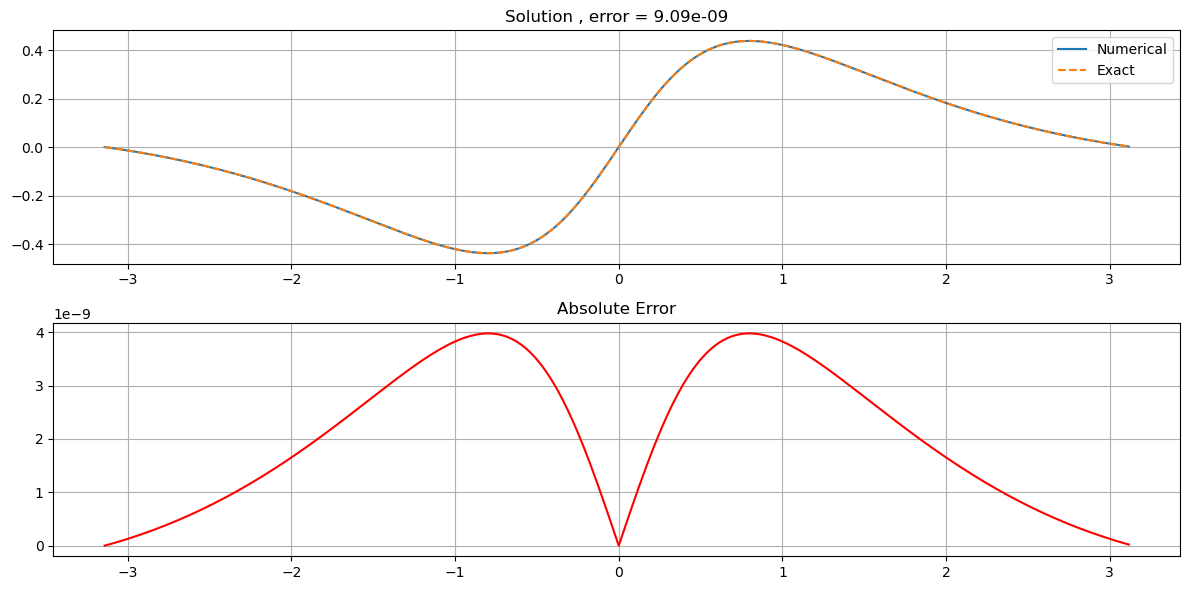

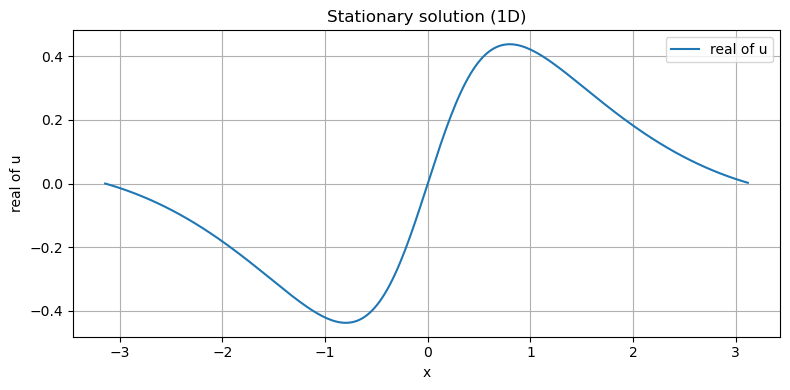

In [4]:
# Symbols
x = symbols('x')
xi = symbols('xi', real=True)
u = Function('u')(x)

# Pseudo-differential equation depending on x
equation = Eq(psiOp(x**2 * xi**2 + 1, u), sin(x))

# Exact solution (approximate here, for visual testing purposes)
def u_exact(x_vals):
    return np.sin(x_vals) / (x_vals**2 + 1)  # Corresponds to the symbol evaluated at xi=1 approximately

# Creation of the solver
solver = PDESolver(equation)

# Grid parameters
Lx = 2 * np.pi
Nx = 256

# Configuration of the solver with Dirichlet condition
solver.setup(
    Lx=Lx,
    Nx=Nx,
    boundary_condition='dirichlet',
    initial_condition=None
)

# Stationary solution with asymptotic inversion of order 1
u_num = solver.solve_stationary_psiOp(order=0)

# Comparison with approximate exact solution
solver.test(u_exact=u_exact, threshold=1, component='real')  # Larger tolerance here

# Visualization
solver.show_stationary_solution(u=u_num, component='real')


## 1D diffusion equation with psiOp


*********************************
* Partial differential equation *
*********************************

∂                   ⎛ 2             ⎞
──(u(t, x)) = -psiOp⎝ξ  + 1, u(t, x)⎠
∂t                                   

********************
* Equation parsing *
********************


Equation rewritten in standard form: psiOp(xi**2 + 1, u(t, x)) + Derivative(u(t, x), t)
⚠️ psiOp detected: skipping expansion for safety

Expanded equation: psiOp(xi**2 + 1, u(t, x)) + Derivative(u(t, x), t)
Analyzing term: psiOp(xi**2 + 1, u(t, x))
  --> Classified as pseudo linear term (psiOp)
Analyzing term: Derivative(u(t, x), t)
  Derivative found: Derivative(u(t, x), t)
  --> Classified as linear
Final linear terms: {Derivative(u(t, x), t): 1}
Final nonlinear terms: []
Symbol terms: []
Pseudo terms: [(1, xi**2 + 1)]
Source terms: []
⚠️  Pseudo‑differential operator detected: all other linear terms have been rejected.

*******************************
* Linear operator computation *
********************

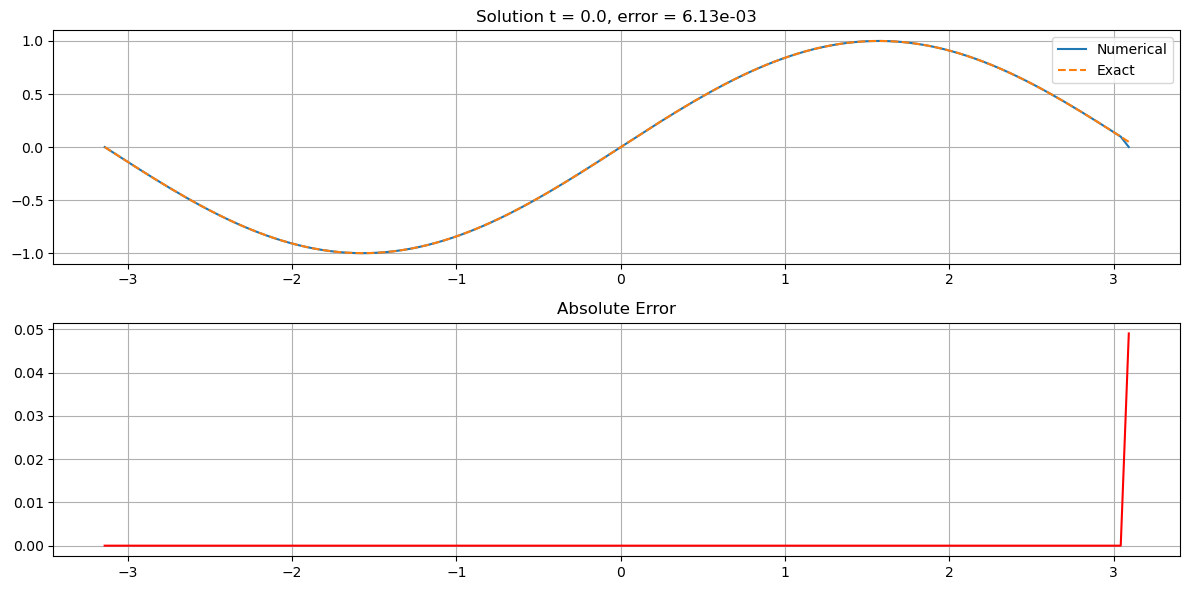

Closest available time to t_eval=0.5: 0.5
Test error t = 0.5: 2.409e-02


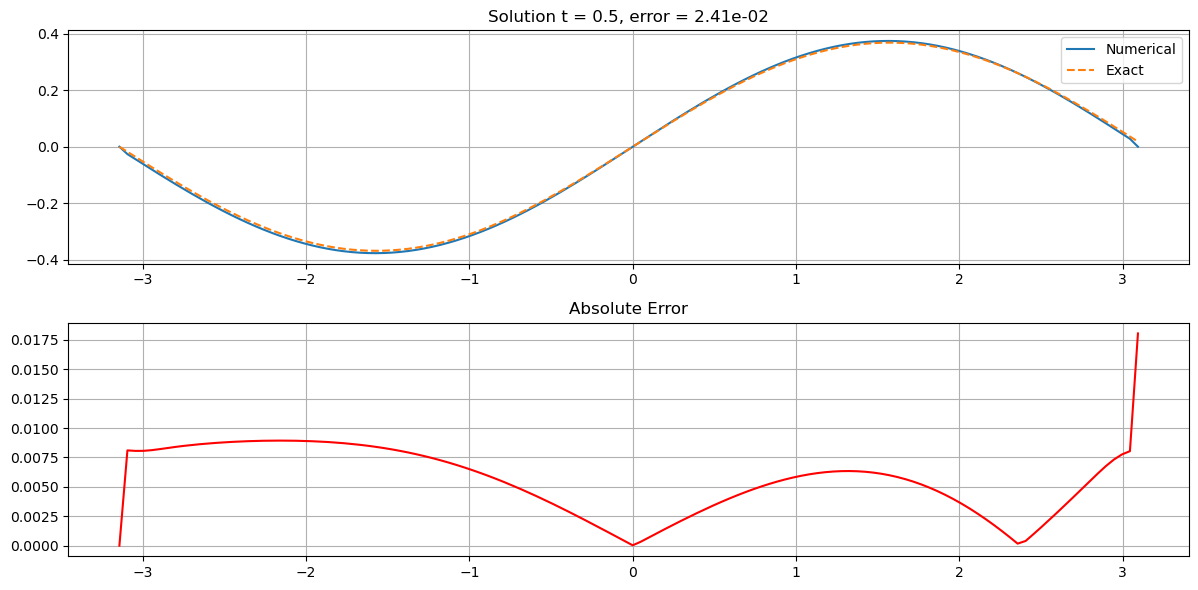

Closest available time to t_eval=1.0: 1.0
Test error t = 1.0: 2.772e-02


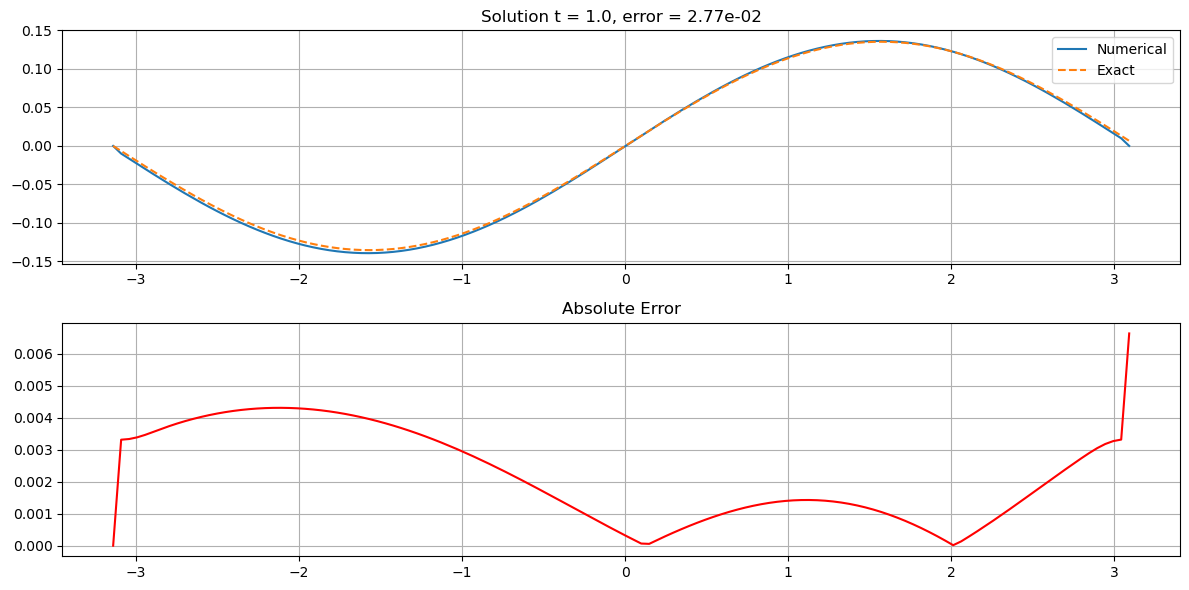

Closest available time to t_eval=1.5: 1.5
Test error t = 1.5: 3.379e-02


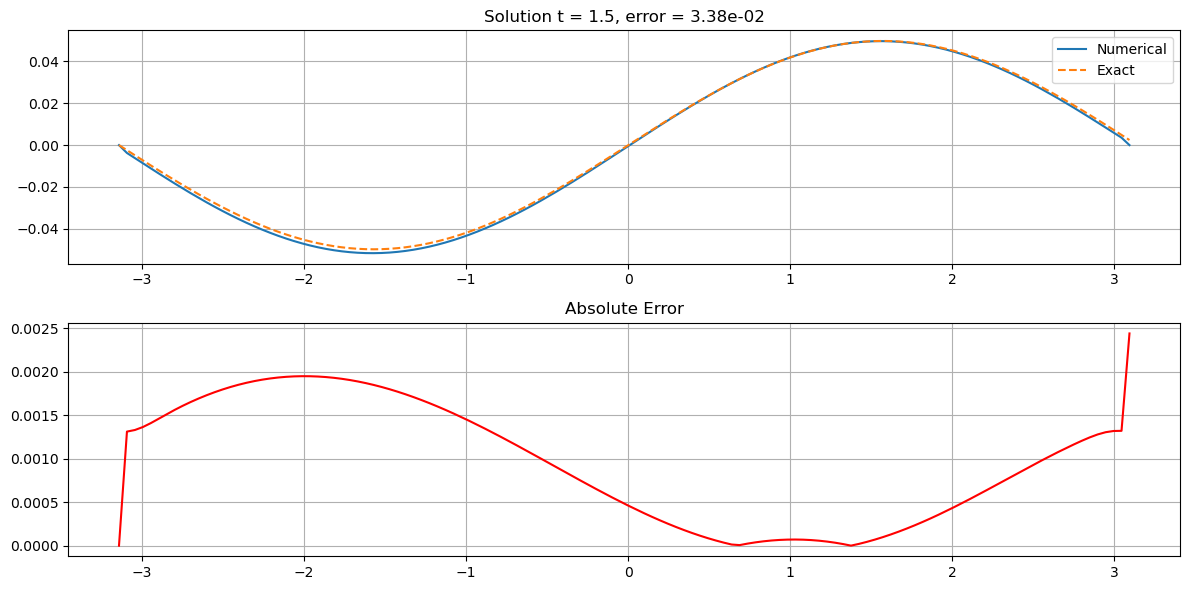

Closest available time to t_eval=2.0: 2.0
Test error t = 2.0: 4.461e-02


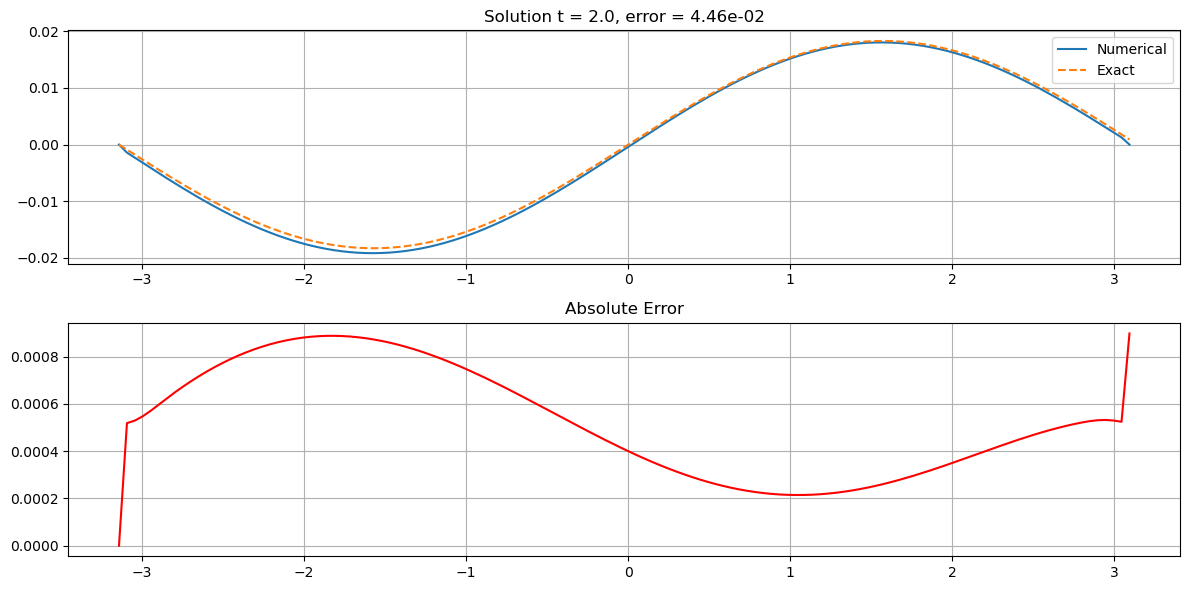

In [5]:
# Definition of symbols
t, x, xi = symbols('t x xi', real=True)
u = Function('u')

# Evolution equation (with psiOp): ∂u/∂t = -psiOp(ξ² + 1, u)
equation = Eq(diff(u(t, x), t), -psiOp(xi**2 + 1, u(t, x)))

# Creation of the solver
solver = PDESolver(equation)

# Parameters
Lx = 2 * np.pi
Nx = 128
Lt = 2.0
Nt = 200

# Initial condition
k0 = 1.0
initial_condition = lambda x: np.sin(k0 * x)

# Exact solution function
def u_exact(x, t):
    return np.sin(k0 * x) * np.exp(- (k0**2 + 1) * t)

# Setup with Dirichlet boundary condition
solver.setup(
    Lx=Lx,
    Nx=Nx,
    Lt=Lt,
    Nt=Nt,
    boundary_condition='dirichlet',
    initial_condition=initial_condition
)

# Solving
solver.solve()

# Automatic tests
n_test = 4
for i in range(n_test + 1):
    solver.test(u_exact=u_exact, t_eval=i * Lt / n_test, threshold=5e-2, component='real')


## 1D wave equation with psiOp


*********************************
* Partial differential equation *
*********************************

 2                                
∂                   ⎛  2         ⎞
───(u(t, x)) = psiOp⎝-ξ , u(t, x)⎠
  2                               
∂t                                

********************
* Equation parsing *
********************


Equation rewritten in standard form: -psiOp(-xi**2, u(t, x)) + Derivative(u(t, x), (t, 2))
⚠️ psiOp detected: skipping expansion for safety

Expanded equation: -psiOp(-xi**2, u(t, x)) + Derivative(u(t, x), (t, 2))
Analyzing term: -psiOp(-xi**2, u(t, x))
  --> Classified as pseudo linear term (psiOp)
Analyzing term: Derivative(u(t, x), (t, 2))
  Derivative found: Derivative(u(t, x), (t, 2))
  --> Classified as linear
Final linear terms: {Derivative(u(t, x), (t, 2)): 1}
Final nonlinear terms: []
Symbol terms: []
Pseudo terms: [(-1, -xi**2)]
Source terms: []
⚠️  Pseudo‑differential operator detected: all other linear terms have been rejected.

******

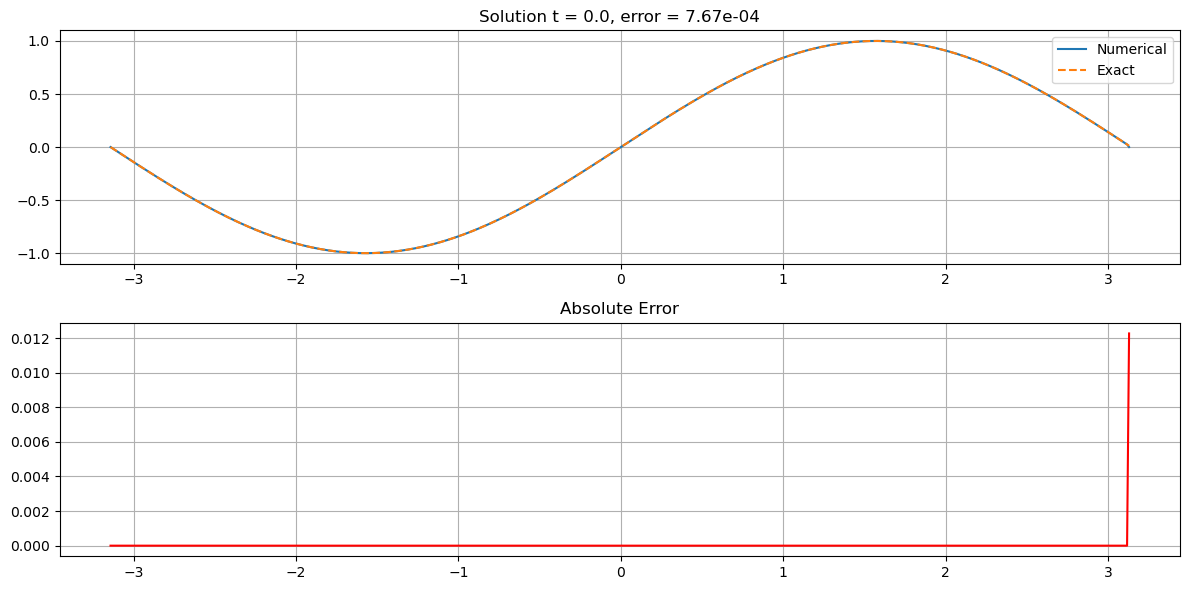

Closest available time to t_eval=0.5: 0.5
Test error t = 0.5: 2.373e-02


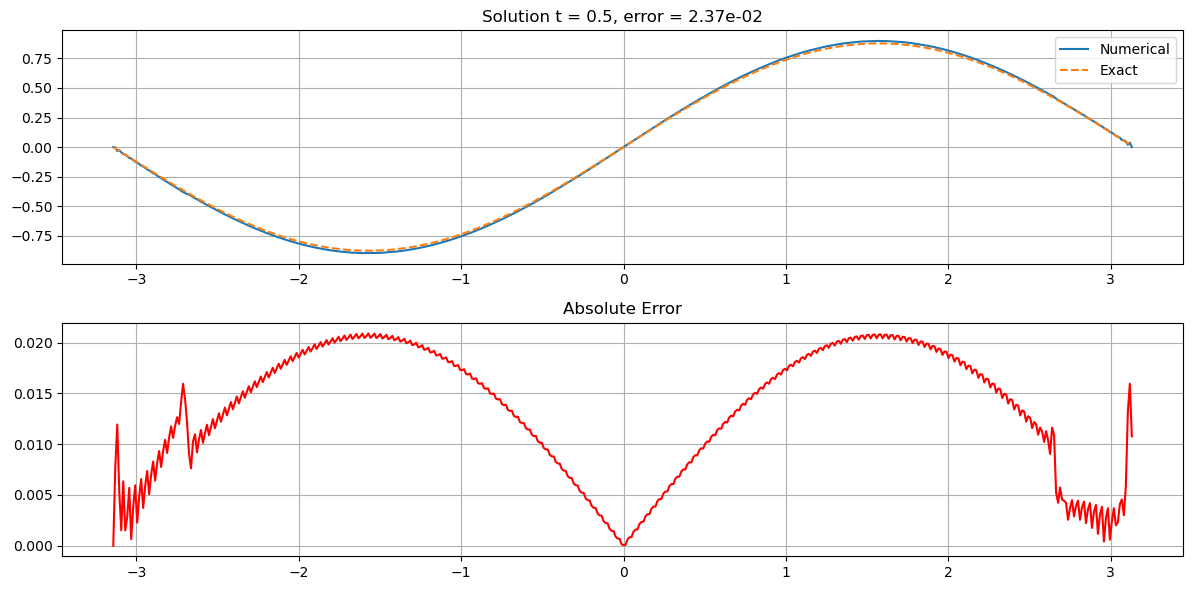

Closest available time to t_eval=1.0: 1.0
Test error t = 1.0: 6.917e-02


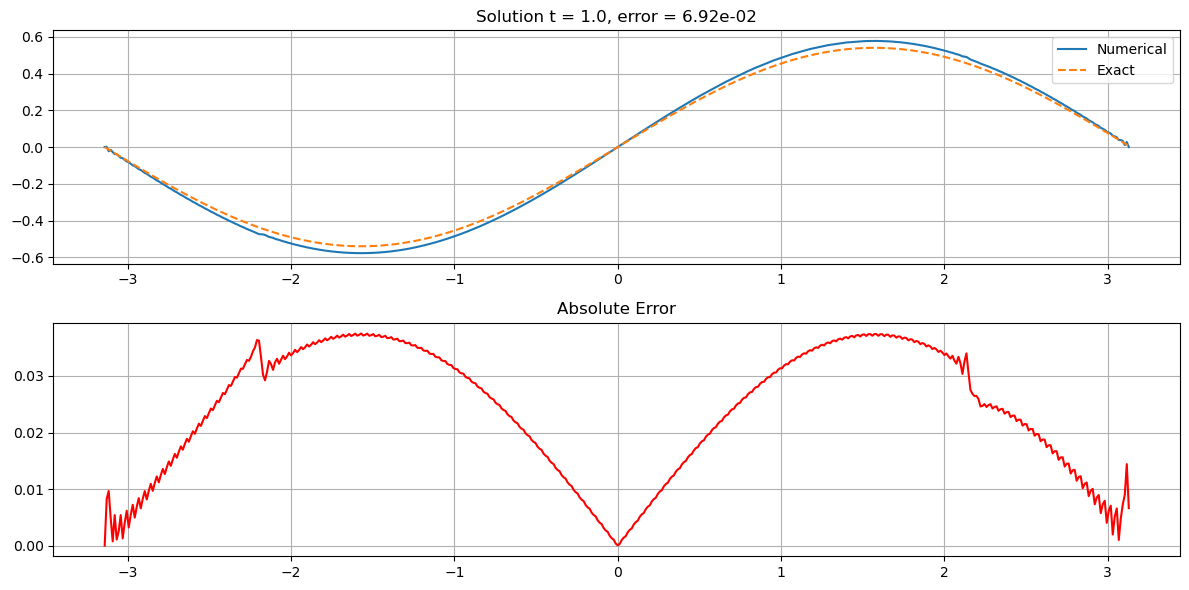

Closest available time to t_eval=1.5: 1.5
Test error t = 1.5: 6.339e-01


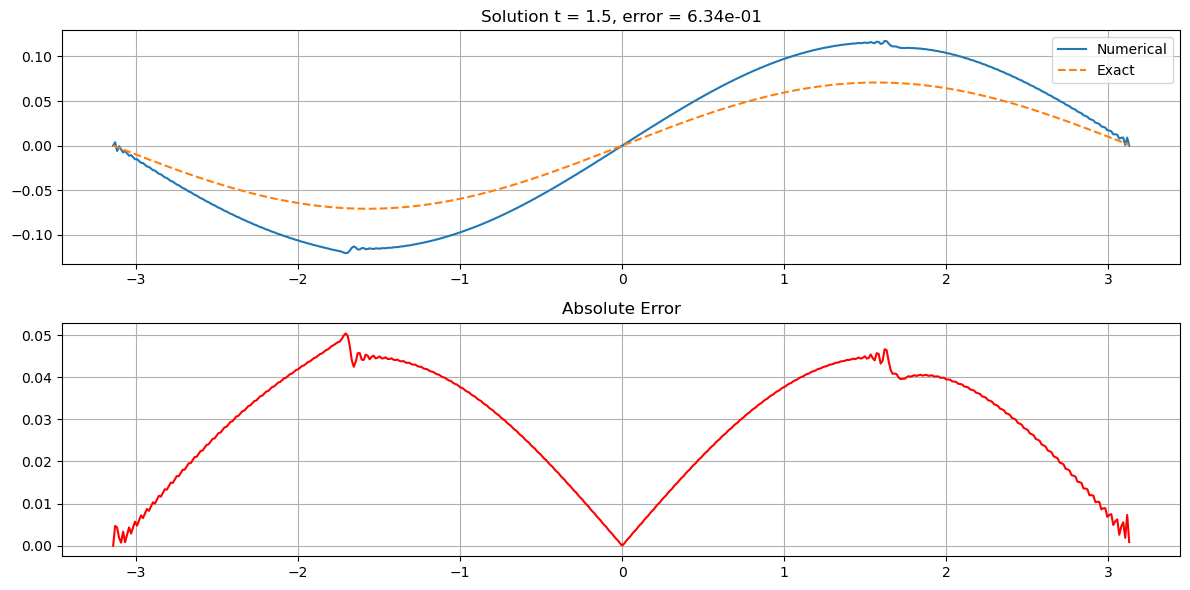

Closest available time to t_eval=2.0: 2.0
Test error t = 2.0: 9.942e-02


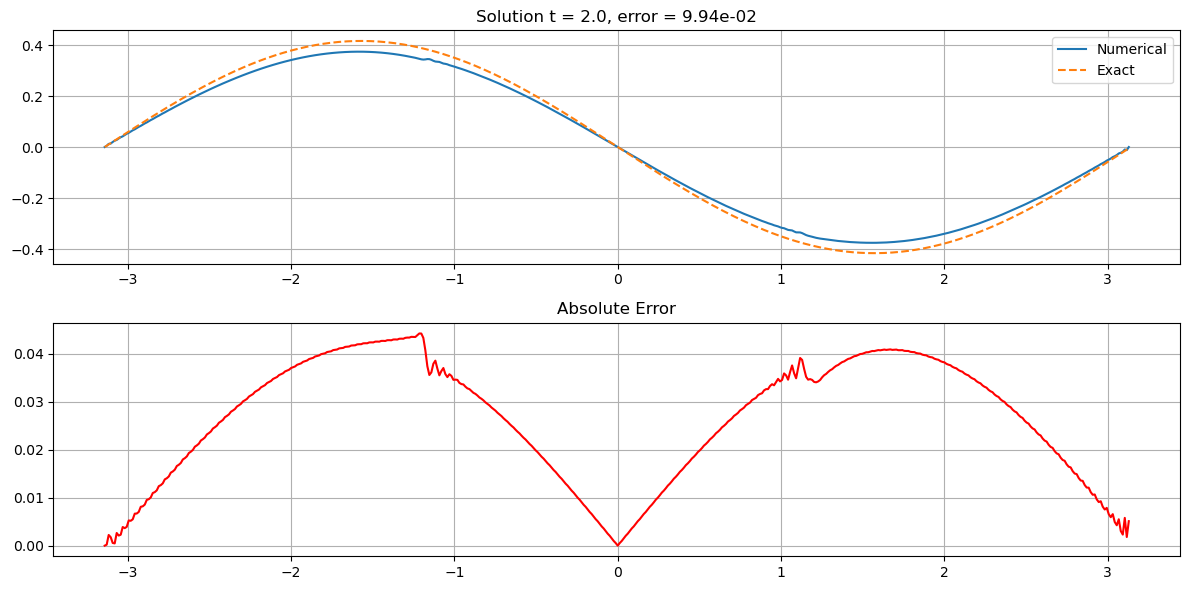

Closest available time to t_eval=2.5: 2.5
Test error t = 2.5: 3.476e-02


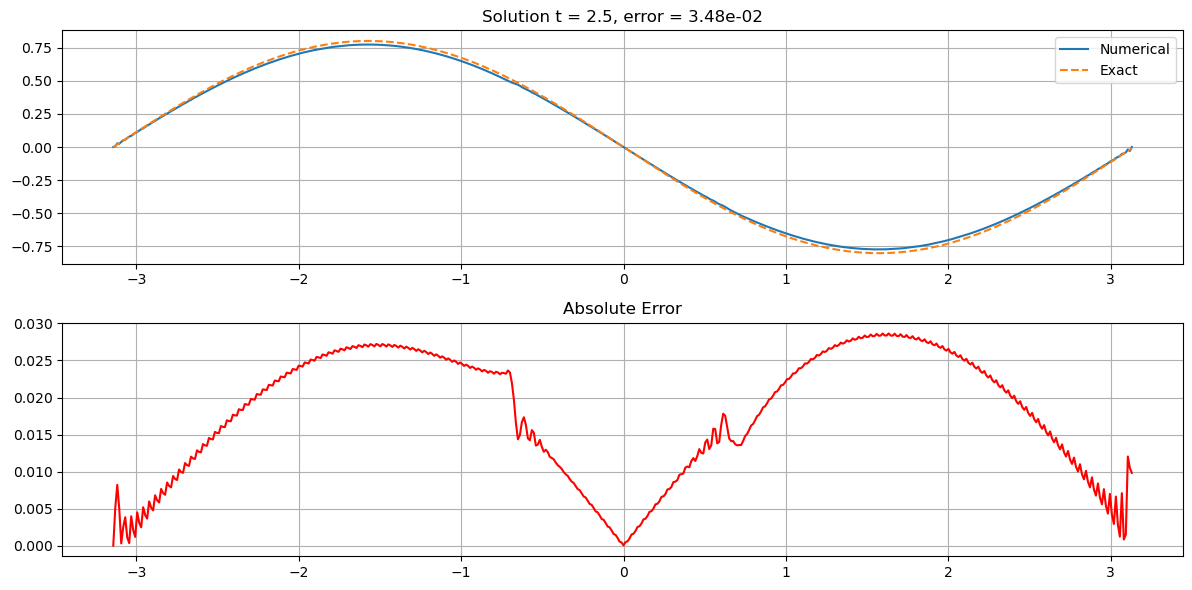

Closest available time to t_eval=3.0: 3.0
Test error t = 3.0: 7.989e-03


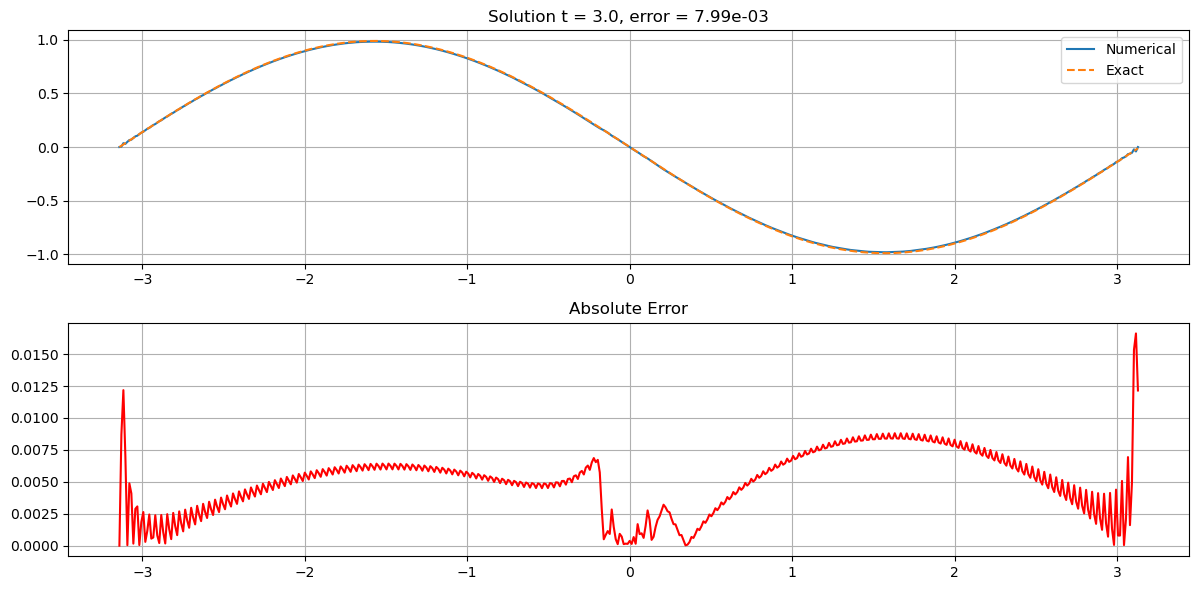

Closest available time to t_eval=3.5: 3.5
Test error t = 3.5: 1.617e-02


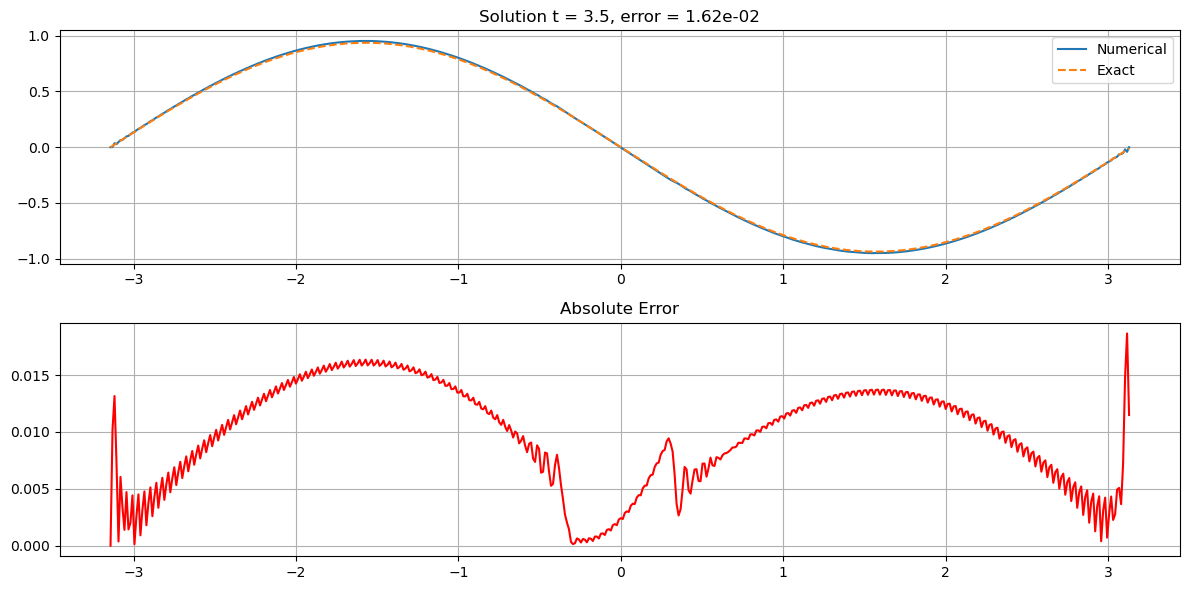

Closest available time to t_eval=4.0: 4.0
Test error t = 4.0: 5.120e-02


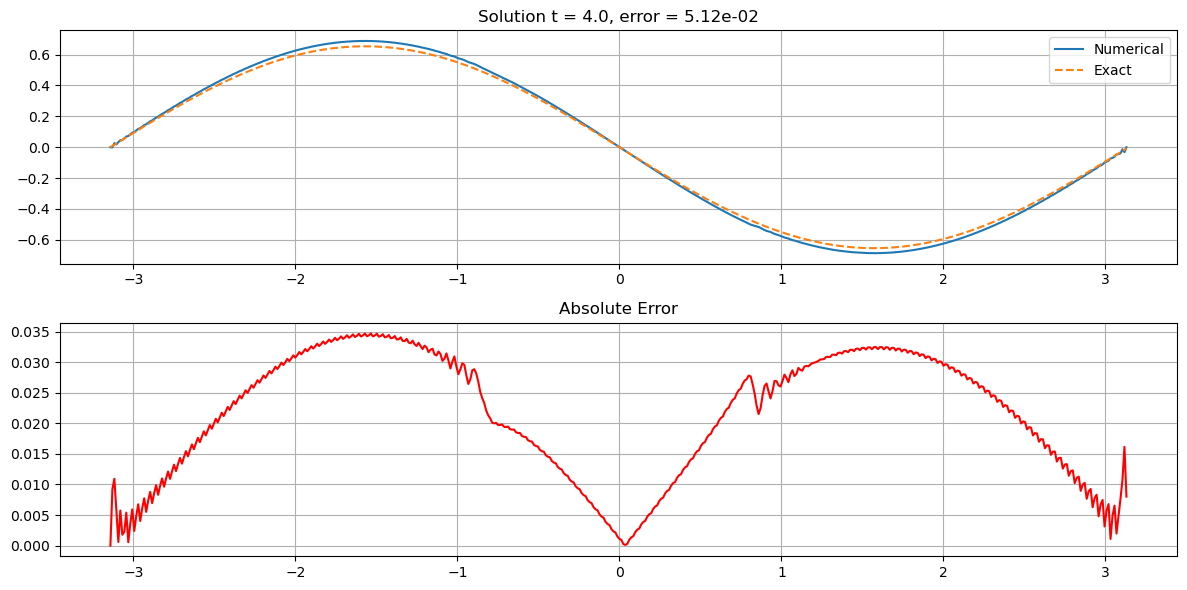

Closest available time to t_eval=4.5: 4.5
Test error t = 4.5: 2.079e-01


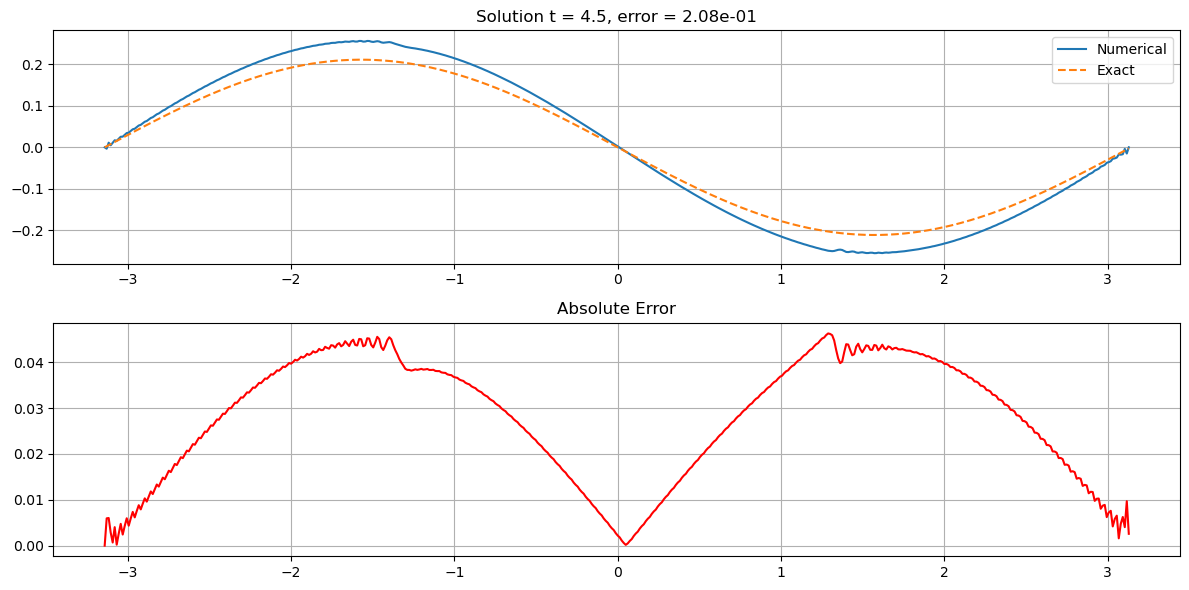

Closest available time to t_eval=5.0: 5.0
Test error t = 5.0: 1.534e-01


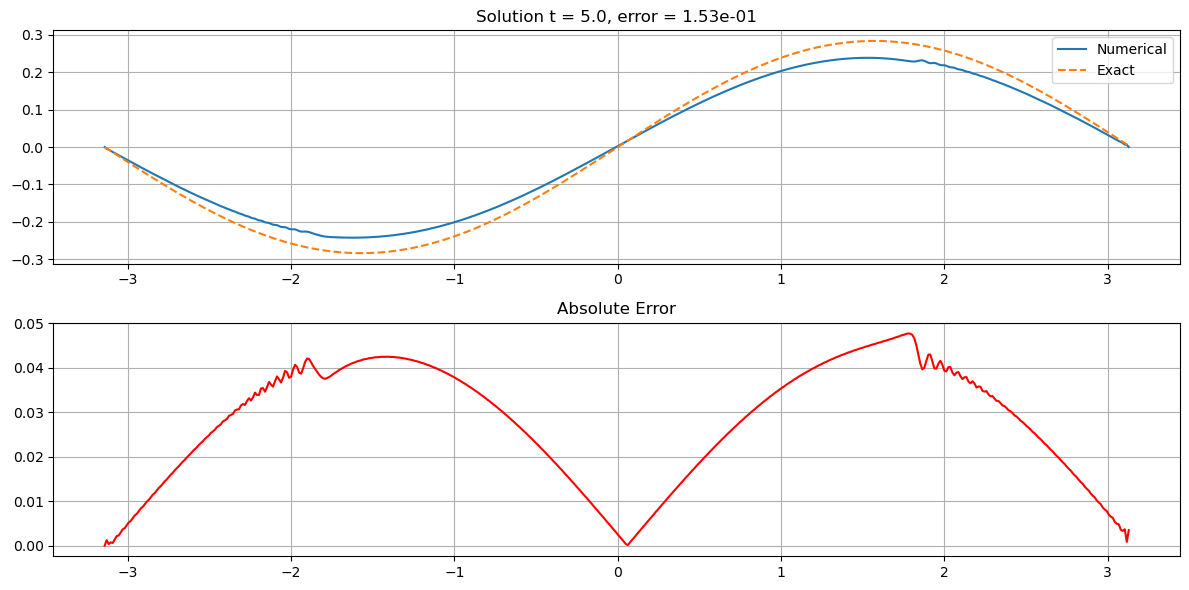

In [6]:
# Symbols
t, x, xi = symbols('t x xi', real=True)
u = Function('u')(t, x)

# Wave equation via psiOp
eq = Eq(diff(u, t, t), psiOp(-xi**2, u))

# Create the solver
solver = PDESolver(eq)

# Parameters
Lt = 5.0
Lx = 2 * np.pi
Nx = 512

# Setup with Dirichlet boundary conditions
solver.setup(
    Lx=Lx,
    Nx=Nx,
    Lt=Lt,
    Nt=1000,
    boundary_condition='dirichlet',
    initial_condition=lambda x: np.sin(x),
    initial_velocity=lambda x: np.zeros_like(x)
)

# Solve
solver.solve()

# Energy visualization
solver.plot_energy()
solver.plot_energy(log=True)

# Exact solution (eigenmode)
def u_exact(x, t):
    return np.sin(x) * np.cos(t)
    
# Automatic tests
n_test = 10
for i in range(n_test + 1):
    solver.test(u_exact=u_exact, t_eval=i * Lt / n_test, threshold=7e-1, component='real')


## 1D Schrodinger equation with psiOp


*********************************
* Partial differential equation *
*********************************

∂                  ⎛   2         ⎞
──(u(t, x)) = psiOp⎝ⅈ⋅ξ , u(t, x)⎠
∂t                                

********************
* Equation parsing *
********************


Equation rewritten in standard form: -psiOp(I*xi**2, u(t, x)) + Derivative(u(t, x), t)
⚠️ psiOp detected: skipping expansion for safety

Expanded equation: -psiOp(I*xi**2, u(t, x)) + Derivative(u(t, x), t)
Analyzing term: -psiOp(I*xi**2, u(t, x))
  --> Classified as pseudo linear term (psiOp)
Analyzing term: Derivative(u(t, x), t)
  Derivative found: Derivative(u(t, x), t)
  --> Classified as linear
Final linear terms: {Derivative(u(t, x), t): 1}
Final nonlinear terms: []
Symbol terms: []
Pseudo terms: [(-1, I*xi**2)]
Source terms: []
⚠️  Pseudo‑differential operator detected: all other linear terms have been rejected.

*******************************
* Linear operator computation *
*******************************



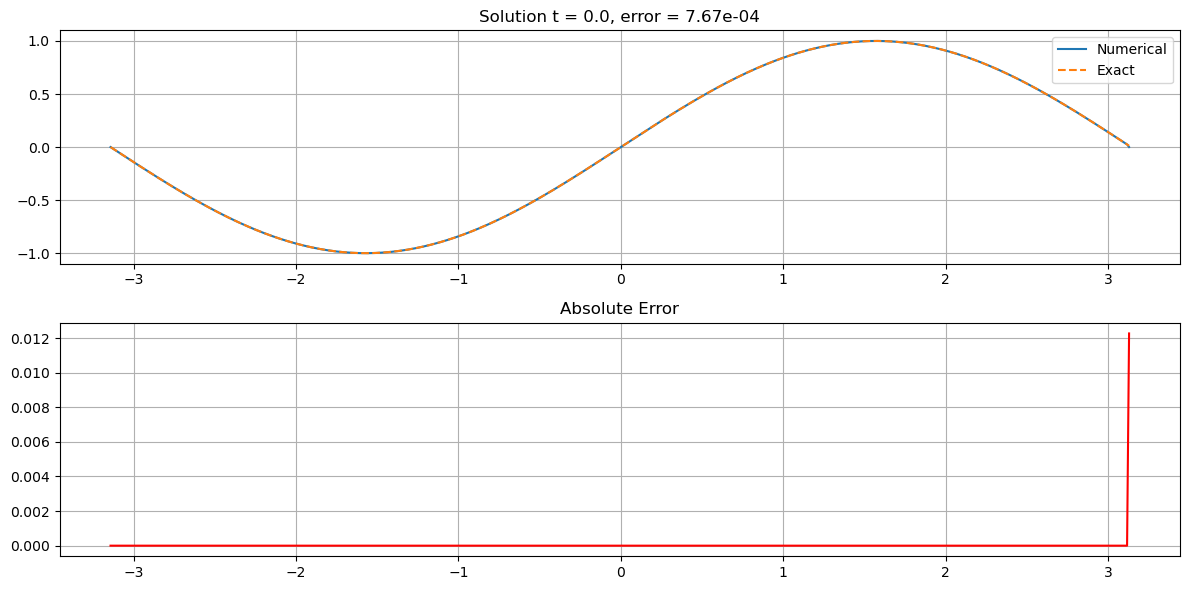

Closest available time to t_eval=1.0: 1.0
Test error t = 1.0: 6.184e-02


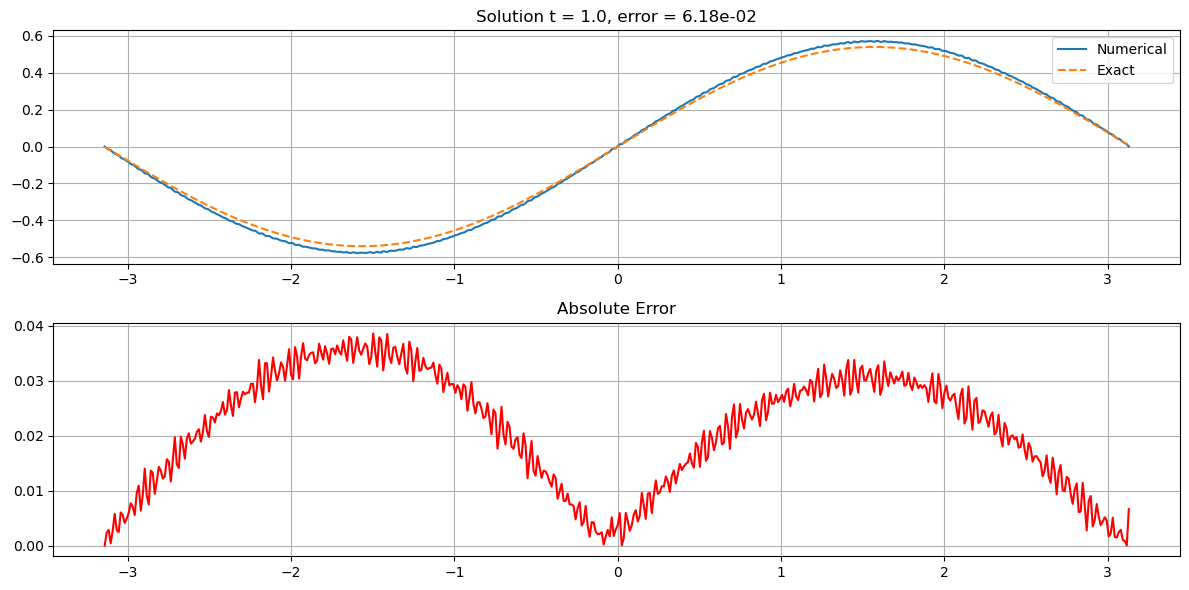

Closest available time to t_eval=2.0: 2.0
Test error t = 2.0: 8.911e-02


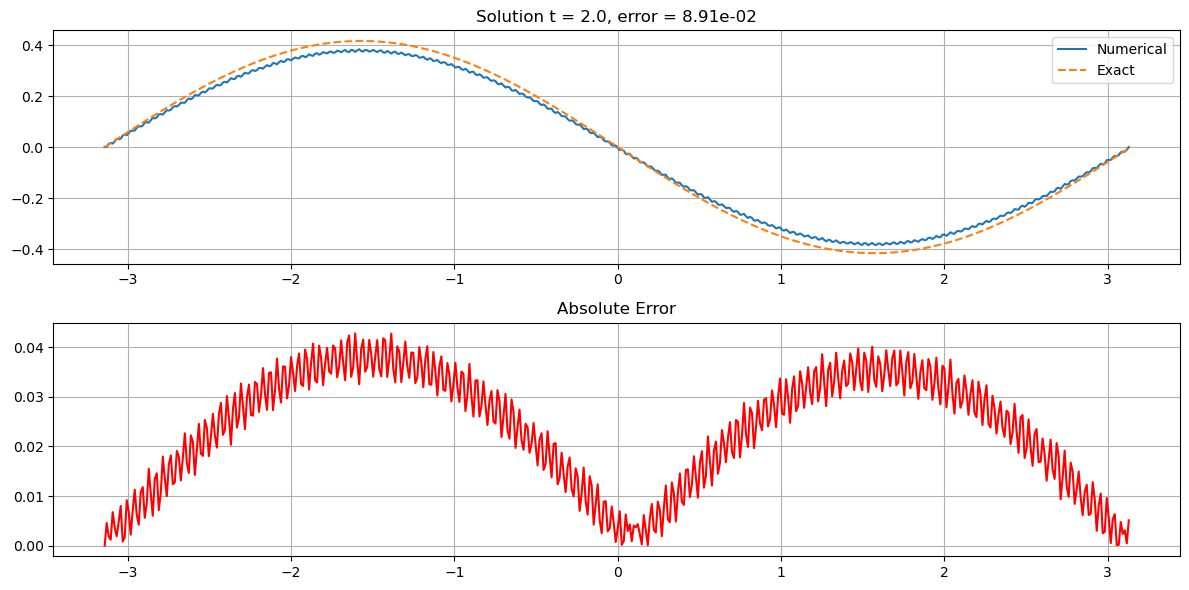

Closest available time to t_eval=3.0: 3.0
Test error t = 3.0: 1.057e-02


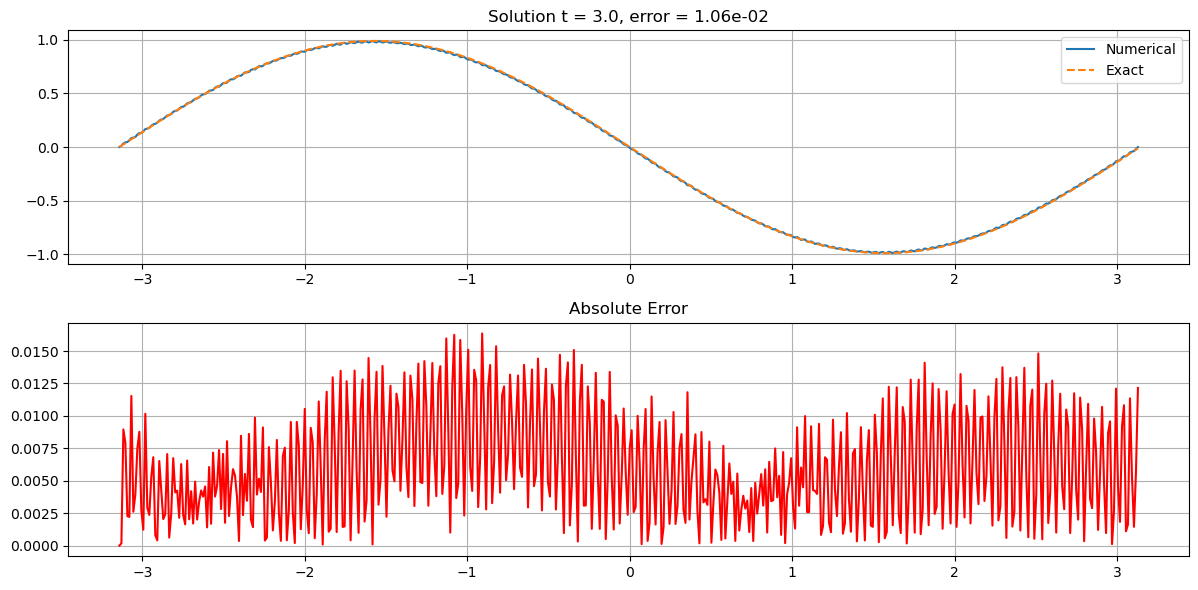

Closest available time to t_eval=4.0: 4.0
Test error t = 4.0: 4.595e-02


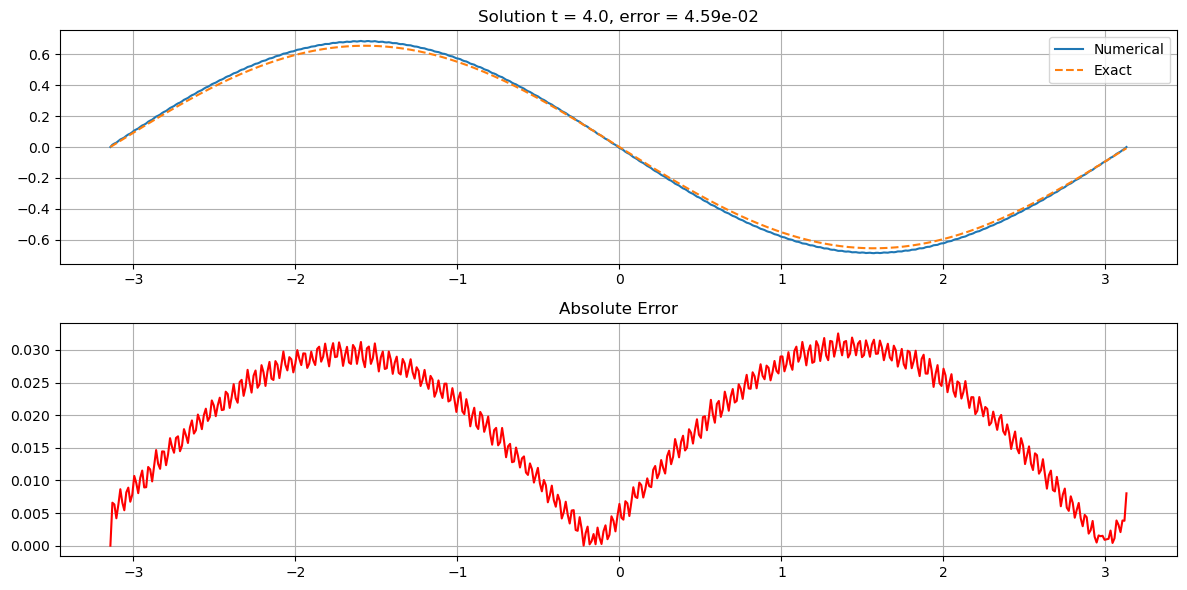

Closest available time to t_eval=5.0: 5.0
Test error t = 5.0: 1.375e-01


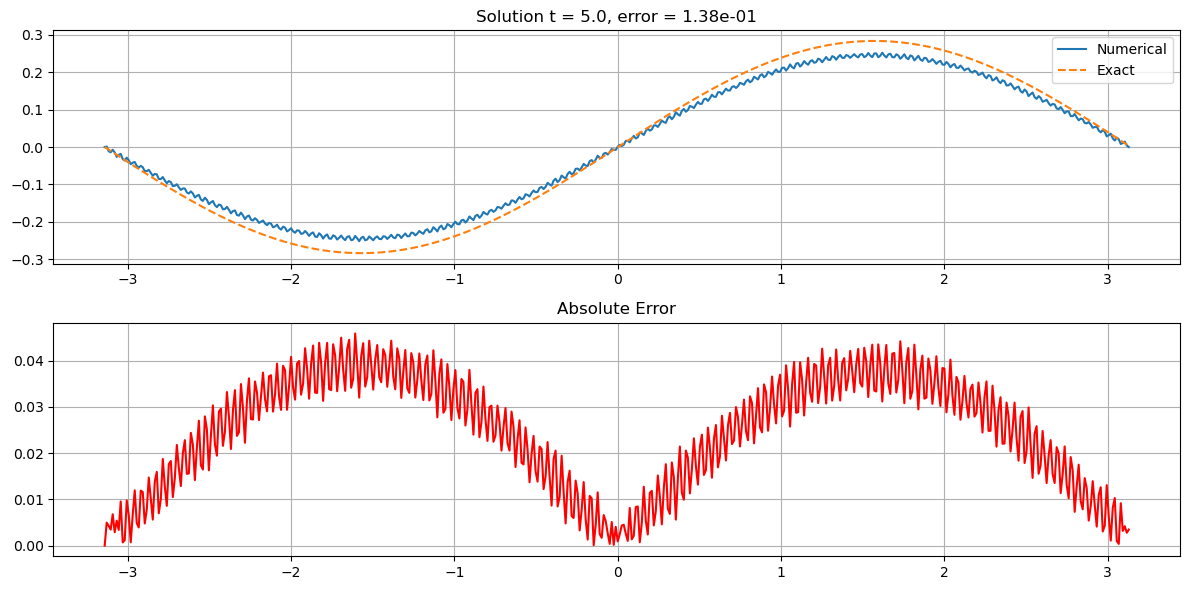

In [7]:
# Definition of symbols
t, x = symbols('t x', real=True)
u = Function('u')(t, x)

# Schrödinger equation (form adapted to the solver)
equation = Eq(diff(u, t), psiOp(I * xi**2, u))

# Creation of the solver
solver = PDESolver(equation)

# Parameters
Lx = 2 * np.pi
Nx = 512
Lt = 5.0
Nt = 500

# Initial condition: localized Gaussian (or sine)
initial_condition = lambda x: np.sin(x)
initial_velocity = None  # not used here
# Setup with Dirichlet conditions
solver.setup(
    Lx=Lx,
    Nx=Nx,
    Lt=Lt,
    Nt=Nt,
    boundary_condition='dirichlet',
    initial_condition=initial_condition
)

# Solving
solver.solve()

# Exact solution 
def u_exact(x, t):
    return np.exp(1j * t) * np.sin(x) 
    
# Tests (if applicable)
n_test = 5
for i in range(n_test + 1):
    solver.test(u_exact=u_exact, t_eval=i * Lt / n_test, threshold=7e-1, component='real')
